In [1]:
import sqlite3
import pandas as pd
import os

os.chdir(r"C:\Users\user\Desktop\Final Project")
os.makedirs("data/results", exist_ok=True)

conn = sqlite3.connect("data/processed/kenya_water.db")

# --- 1. Inspect actual column names ---
cols_df = pd.read_sql_query("PRAGMA table_info(kewi_water_tests)", conn)
print("KEWI columns in database:")
for _, r in cols_df.iterrows():
    print(f"   '{r['name']}'  ({r['type']})")

cols = cols_df["name"].tolist()

def find(candidates):
    for cand in candidates:
        for c in cols:
            if c.lower().strip() == cand.lower():
                return c
    return None

kewi_county = find(["COUNTY", "county"])
kewi_source = find(["TYPE_OF_", "TYPE_OF", "SOURCE"])
kewi_ph     = find(["PH", "ph"])
kewi_cond   = find(["CONDUCTIVITY", "conductivity", "COND"])
kewi_tds    = find(["Total_Dissolved", "TDS", "total_dissolved"])

print(f"\nDetected: county={kewi_county}, source={kewi_source}, pH={kewi_ph}, cond={kewi_cond}, tds={kewi_tds}")

# --- 2. Confirmation: how many rows? ---
n = pd.read_sql_query("SELECT COUNT(*) AS n FROM kewi_water_tests", conn)["n"][0]
print(f"\nTotal KEWI rows: {n}")

# --- 3. KEWI by county ---
if kewi_county and kewi_ph:
    q = f"""
        SELECT 
            "{kewi_county}" AS county,
            COUNT(*) AS total_tests,
            ROUND(AVG("{kewi_ph}"), 2) AS avg_ph,
            COUNT("{kewi_ph}") AS ph_tests
    """
    if kewi_cond:
        q += f', ROUND(AVG("{kewi_cond}"), 1) AS avg_conductivity, COUNT("{kewi_cond}") AS cond_tests'
    if kewi_tds:
        q += f', ROUND(AVG("{kewi_tds}"), 1) AS avg_tds, COUNT("{kewi_tds}") AS tds_tests'
    q += f' FROM kewi_water_tests WHERE "{kewi_county}" IS NOT NULL GROUP BY "{kewi_county}" ORDER BY avg_ph DESC'

    by_county = pd.read_sql_query(q, conn)
    by_county.to_csv("data/results/03_kewi_by_county.csv", index=False)
    print(f"\n✅ 03_kewi_by_county.csv saved ({len(by_county)} rows)")
    print(by_county.to_string(index=False))

# --- 4. KEWI by source ---
if kewi_source and kewi_ph:
    q = f"""
        SELECT 
            "{kewi_source}" AS source_type,
            COUNT(*) AS total_tests,
            ROUND(AVG("{kewi_ph}"), 2) AS avg_ph
    """
    if kewi_cond:
        q += f', ROUND(AVG("{kewi_cond}"), 1) AS avg_conductivity'
    if kewi_tds:
        q += f', ROUND(AVG("{kewi_tds}"), 1) AS avg_tds'
    q += f' FROM kewi_water_tests WHERE "{kewi_source}" IS NOT NULL GROUP BY "{kewi_source}" ORDER BY total_tests DESC'

    by_source = pd.read_sql_query(q, conn)
    by_source.to_csv("data/results/04_kewi_by_source.csv", index=False)
    print(f"\n✅ 04_kewi_by_source.csv saved ({len(by_source)} rows)")
    print(by_source.to_string(index=False))

# --- 5. Source breakdown ---
if kewi_source:
    breakdown = pd.read_sql_query(
        f'SELECT "{kewi_source}" AS source, COUNT(*) AS tests FROM kewi_water_tests GROUP BY "{kewi_source}" ORDER BY tests DESC',
        conn
    )
    breakdown.to_csv("data/results/07_kewi_source_breakdown.csv", index=False)
    print(f"\n✅ 07_kewi_source_breakdown.csv saved ({len(breakdown)} rows)")
    print(breakdown.to_string(index=False))

conn.close()
print("\n✅ All KEWI CSVs extracted")

KEWI columns in database:
   'SAMPLE_NO'  (TEXT)
   'DATE'  (TEXT)
   'TYPE_OF_H2O'  (TEXT)
   'COUNTY'  (TEXT)
   'TYPE_OF_ANALYSIS'  (TEXT)
   'PH'  (REAL)
   'ALKALINITY_Mg/L'  (TEXT)
   'CONDUCTIVITY?S/cm'  (TEXT)
   'Total_Dissolved_Solids'  (TEXT)
   'COLOUR'  (TEXT)
   'OBJECTID'  (INTEGER)

Detected: county=COUNTY, source=None, pH=PH, cond=None, tds=None

Total KEWI rows: 493

✅ 03_kewi_by_county.csv saved (53 rows)
                                   county  total_tests  avg_ph  ph_tests
                                  Homabay            1    8.50         1
                                     Embu            4    8.25         4
                                 Marsabit            9    8.13         9
                                    Sondu            1    8.10         1
                                  Central            1    8.00         1
                                   Isiolo            2    7.95         2
                                 Machakos           86    7.8

In [3]:
import os, re, sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir(r"C:\Users\user\Desktop\Final Project")
os.makedirs("output/charts", exist_ok=True)
os.makedirs("output/results", exist_ok=True)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

# Load all three datasets
conn = sqlite3.connect("data/processed/kenya_water.db")
national = pd.read_sql_query("SELECT * FROM national_indicators", conn)
athi     = pd.read_sql_query("SELECT * FROM athi_river_coverage", conn)
kewi     = pd.read_sql_query("SELECT * FROM kewi_water_tests", conn)
conn.close()

# Convert numeric-looking text columns in KEWI
for col in kewi.columns:
    if any(k in col.lower() for k in ["ph", "conductivity", "total", "alkalinity"]):
        kewi[col] = pd.to_numeric(kewi[col], errors="coerce")

# Athi coverage % → numeric; date → year
athi["Coverage_%"] = pd.to_numeric(athi["Coverage_%"].astype(str).str.replace("%", ""), errors="coerce")
athi["year"] = pd.to_datetime(athi["Date"], errors="coerce").dt.year

findings = []
print(f"✅ Loaded")
print(f"   national: {national.shape}")
print(f"   athi:     {athi.shape}")
print(f"   kewi:     {kewi.shape}")

✅ Loaded
   national: (99, 8)
   athi:     (8, 10)
   kewi:     (493, 11)


C:\Users\user\AppData\Local\Temp\ipykernel_17052\3639172420.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  athi["year"] = pd.to_datetime(athi["Date"], errors="coerce").dt.year


In [4]:
def norm(s):
    """Strip everything except letters and numbers."""
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def find_col(df, candidates):
    """Find first column whose normalized name contains a candidate."""
    cols_norm = {c: norm(c) for c in df.columns}
    for cand in candidates:
        cand_n = norm(cand)
        for c, cn in cols_norm.items():
            if cand_n == cn or cand_n in cn or cn in cand_n:
                return c
    return None

# Detect KEWI columns
kewi_county = find_col(kewi, ["COUNTY"])
kewi_source = find_col(kewi, ["TYPE_OF_H2O", "TYPE_OF_WATER", "SOURCE", "TYPE_OF"])
kewi_ph     = find_col(kewi, ["PH"])
kewi_cond   = find_col(kewi, ["CONDUCTIVITY", "COND"])
kewi_tds    = find_col(kewi, ["TOTAL_DISSOLVED", "TDS"])

# Detect Athi columns
a_type   = find_col(athi, ["TYPE_OF_COVERAGE"])
a_cov    = find_col(athi, ["COVERAGE"])
a_served = find_col(athi, ["SERVED_POP", "SERVED"])
a_unserv = find_col(athi, ["NON_SERVED", "UNSERVED"])

print("Detected columns:")
print(f"   KEWI: county={kewi_county}, source={kewi_source}, pH={kewi_ph}, cond={kewi_cond}, tds={kewi_tds}")
print(f"   Athi: type={a_type}, coverage={a_cov}, served={a_served}, unserved={a_unserv}")

Detected columns:
   KEWI: county=COUNTY, source=TYPE_OF_H2O, pH=PH, cond=CONDUCTIVITY?S/cm, tds=Total_Dissolved_Solids
   Athi: type=Type_of_Coverage, coverage=Type_of_Coverage, served=Served_Pop, unserved=Non_served_Pop


In [6]:
print("=" * 70)
print("GENERAL DATA UNDERSTANDING")
print("=" * 70)

def eda(df, name, numeric_cols=None, categorical_cols=None):
    print(f"\n📋 {name}")
    print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"   Duplicates: {df.duplicated().sum()}")

    print(f"\n   Missing values:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("      None")
    else:
        for c, n in missing.items():
            if n > 0:
                print(f"      {c:30s} {n:>4} ({n/len(df)*100:.1f}%)")

    if numeric_cols:
        existing = [c for c in numeric_cols if c in df.columns]
        if existing:
            print(f"\n   Numeric summary:")
            print(df[existing].describe().round(2).to_string())

    if categorical_cols:
        for c in categorical_cols:
            if c in df.columns:
                print(f"\n   Top values in '{c}':")
                print(df[c].value_counts().head(8).to_string())

eda(national, "national_indicators",
    numeric_cols=["value", "year"],
    categorical_cols=["indicator_name"])

eda(athi, "athi_river_coverage",
    numeric_cols=["Total_Pop", "Coverage_%", "Served_Pop", "Non_served_Pop"])

eda(kewi, "kewi_water_tests",
    numeric_cols=[kewi_ph, kewi_cond, kewi_tds],
    categorical_cols=[kewi_county, kewi_source])

GENERAL DATA UNDERSTANDING

📋 national_indicators
   Shape: 99 rows × 8 columns
   Duplicates: 0

   Missing values:
      None

   Numeric summary:
       value     year
count  99.00    99.00
mean   28.83  2011.84
std    18.18     7.13
min     5.91  2000.00
25%    13.62  2006.00
50%    24.32  2012.00
75%    43.12  2018.00
max    65.60  2024.00

   Top values in 'indicator_name':
indicator_name
Basic drinking water services (% pop)              25
Basic sanitation services (% pop)                  25
Open defecation (% pop)                            25
Freshwater withdrawal (% of internal resources)    23
Mortality from unsafe WASH (per 100k)               1

📋 athi_river_coverage
   Shape: 8 rows × 10 columns
   Duplicates: 0

   Missing values:
      None

   Numeric summary:
        Total_Pop  Coverage_%  Served_Pop  Non_served_Pop
count        8.00        8.00        8.00            8.00
mean   5510044.25       66.25  3678740.00      1875076.38
std     175434.36        3.24   2989

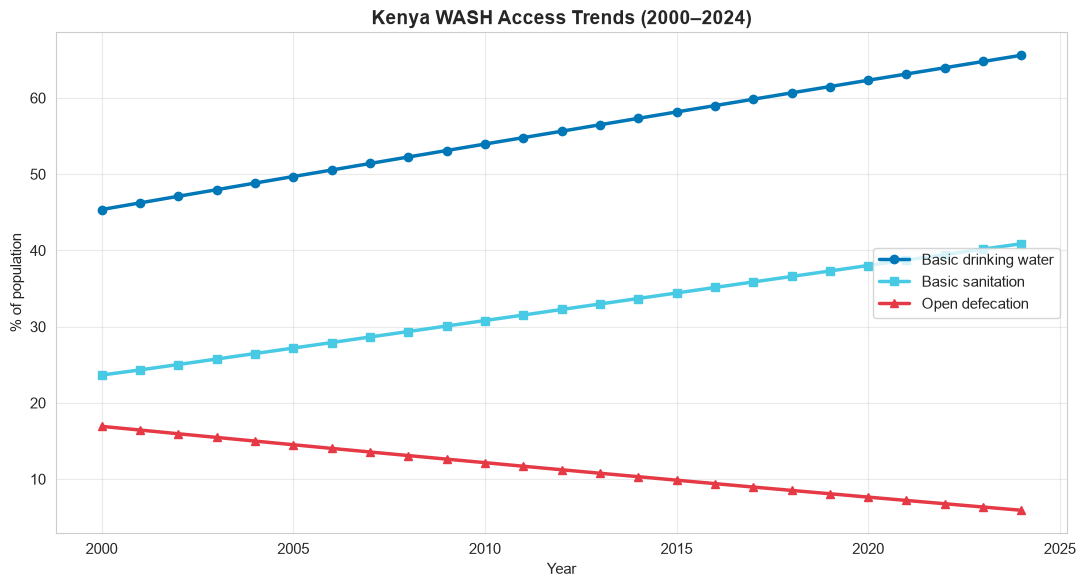


📝 Between 2000 and 2024, basic drinking water access rose from 45.4% to 65.6% (+20.2 pp). Basic sanitation rose from 23.6% to 40.9% (+17.2 pp). Open defecation fell from 16.9% to 5.9% (−11.0 pp). Sanitation still lags water access by 24.7 pp.


In [7]:
trend = national[national["indicator_code"].isin(
    ["SH.H2O.BASW.ZS", "SH.STA.BASS.ZS", "SH.STA.ODFC.ZS"]
)].pivot_table(index="year", columns="indicator_code", values="value", aggfunc="max")

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(trend.index, trend["SH.H2O.BASW.ZS"], marker="o", label="Basic drinking water", color="#0077b6", linewidth=2.5)
ax.plot(trend.index, trend["SH.STA.BASS.ZS"], marker="s", label="Basic sanitation", color="#48cae4", linewidth=2.5)
ax.plot(trend.index, trend["SH.STA.ODFC.ZS"], marker="^", label="Open defecation", color="#e63946", linewidth=2.5)
ax.set_title("Kenya WASH Access Trends (2000–2024)", fontsize=14)
ax.set_xlabel("Year"); ax.set_ylabel("% of population")
ax.legend(loc="center right"); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("output/charts/01_national_trends.png", dpi=150, bbox_inches="tight")
plt.show()

w0, w1 = trend["SH.H2O.BASW.ZS"].iloc[0], trend["SH.H2O.BASW.ZS"].iloc[-1]
s0, s1 = trend["SH.STA.BASS.ZS"].iloc[0], trend["SH.STA.BASS.ZS"].iloc[-1]
o0, o1 = trend["SH.STA.ODFC.ZS"].iloc[0], trend["SH.STA.ODFC.ZS"].iloc[-1]
findings.append(("Chart 1: National WASH Trends",
    f"Between 2000 and 2024, basic drinking water access rose from {w0:.1f}% to {w1:.1f}% (+{w1-w0:.1f} pp). "
    f"Basic sanitation rose from {s0:.1f}% to {s1:.1f}% (+{s1-s0:.1f} pp). "
    f"Open defecation fell from {o0:.1f}% to {o1:.1f}% (−{o0-o1:.1f} pp). "
    f"Sanitation still lags water access by {w1-s1:.1f} pp."))
print(f"\n📝 {findings[-1][1]}")

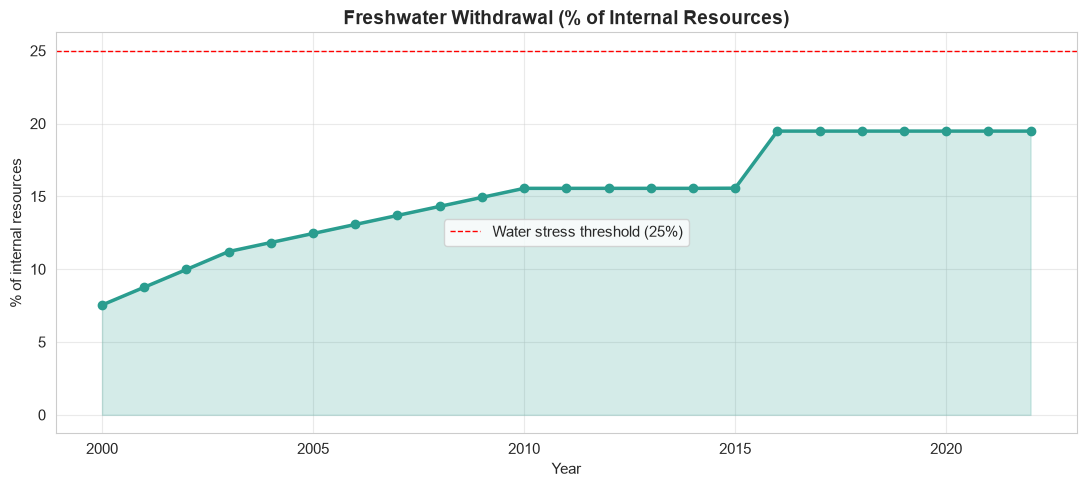


📝 Freshwater withdrawal rose from 7.5% in 2000 to 19.5% in 2022 — still below the 25% water stress threshold but rising steadily.


In [8]:
fresh = national[national["indicator_code"] == "ER.H2O.FWTL.ZS"].sort_values("year")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fresh["year"], fresh["value"], marker="o", color="#2a9d8f", linewidth=2.5)
ax.fill_between(fresh["year"], fresh["value"], alpha=0.2, color="#2a9d8f")
ax.axhline(25, color="red", linestyle="--", linewidth=1, label="Water stress threshold (25%)")
ax.set_title("Freshwater Withdrawal (% of Internal Resources)", fontsize=14)
ax.set_xlabel("Year"); ax.set_ylabel("% of internal resources")
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("output/charts/02_freshwater_withdrawal.png", dpi=150, bbox_inches="tight")
plt.show()

fw0, fw1 = fresh["value"].iloc[0], fresh["value"].iloc[-1]
findings.append(("Chart 2: Freshwater Withdrawal",
    f"Freshwater withdrawal rose from {fw0:.1f}% in {fresh['year'].iloc[0]} to {fw1:.1f}% in "
    f"{fresh['year'].iloc[-1]} — still below the 25% water stress threshold but rising steadily."))
print(f"\n📝 {findings[-1][1]}")

C:\Users\user\AppData\Local\Temp\ipykernel_17052\1281081238.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_county, x="avg_ph", y=kewi_county, palette="viridis", ax=ax)


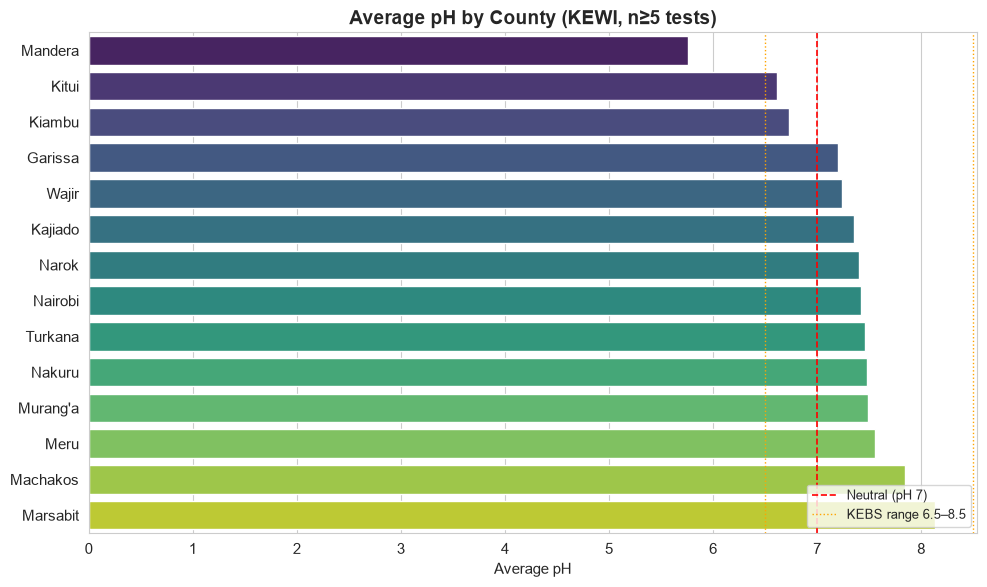


📝 Average pH ranged from 5.76 (Mandera) to 8.13 (Marsabit). 13 of 14 counties fall within the KEBS range 6.5–8.5.


In [9]:
by_county = kewi.groupby(kewi_county).agg(
    total_tests=(kewi_ph, "size"),
    avg_ph=(kewi_ph, "mean"),
    ph_tests=(kewi_ph, "count")
).round(2).reset_index()
by_county = by_county[by_county["ph_tests"] >= 5].sort_values("avg_ph")
by_county.to_csv("output/results/03_kewi_by_county.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(by_county)*0.35)))
sns.barplot(data=by_county, x="avg_ph", y=kewi_county, palette="viridis", ax=ax)
ax.axvline(7.0, color="red", linestyle="--", linewidth=1.2, label="Neutral (pH 7)")
ax.axvline(6.5, color="orange", linestyle=":", linewidth=1, label="KEBS range 6.5–8.5")
ax.axvline(8.5, color="orange", linestyle=":", linewidth=1)
ax.set_title("Average pH by County (KEWI, n≥5 tests)", fontsize=14)
ax.set_xlabel("Average pH"); ax.set_ylabel("")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("output/charts/03_ph_by_county.png", dpi=150, bbox_inches="tight")
plt.show()

high = by_county.iloc[-1]; low = by_county.iloc[0]
in_range = ((by_county["avg_ph"] >= 6.5) & (by_county["avg_ph"] <= 8.5)).sum()
findings.append(("Chart 3: pH by County",
    f"Average pH ranged from {low['avg_ph']:.2f} ({low[kewi_county]}) to {high['avg_ph']:.2f} "
    f"({high[kewi_county]}). {in_range} of {len(by_county)} counties fall within the KEBS range 6.5–8.5."))
print(f"\n📝 {findings[-1][1]}")

C:\Users\user\AppData\Local\Temp\ipykernel_17052\3522216118.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=by_source, x=kewi_source, y="avg_cond", palette="crest", ax=ax)


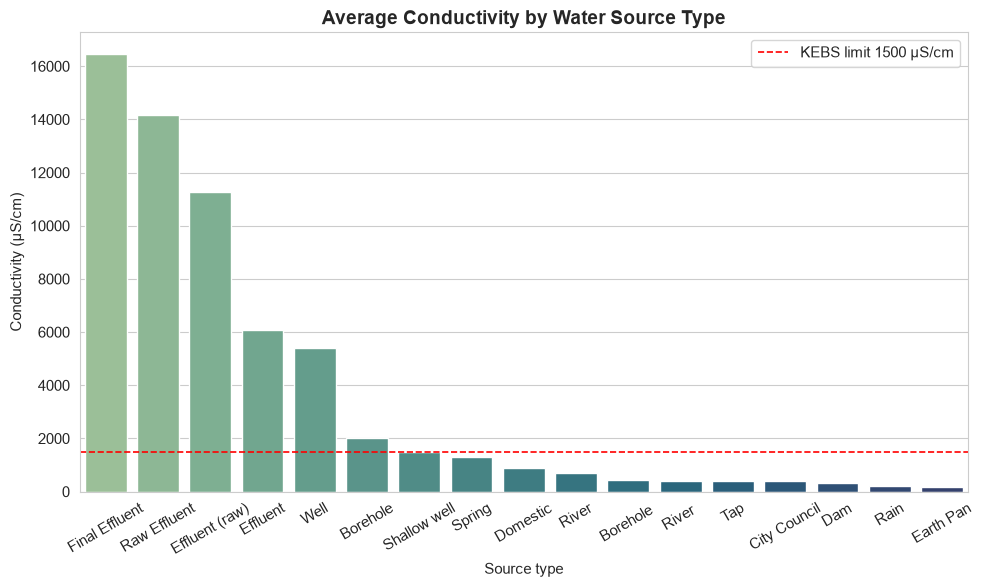


📝 Final Effluent had the highest average conductivity at 16446.1 µS/cm (n=21). This exceeds the KEBS limit of 1500 µS/cm.


In [10]:
if kewi_source and kewi_cond and kewi[kewi_cond].notna().sum() > 0:
    by_source = kewi.groupby(kewi_source).agg(
        avg_cond=(kewi_cond, "mean"),
        cond_tests=(kewi_cond, "count")
    ).round(1).reset_index()
    by_source = by_source[by_source["cond_tests"] >= 3].sort_values("avg_cond", ascending=False)
    by_source.to_csv("output/results/04_kewi_by_source.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=by_source, x=kewi_source, y="avg_cond", palette="crest", ax=ax)
    ax.axhline(1500, color="red", linestyle="--", linewidth=1.2, label="KEBS limit 1500 µS/cm")
    ax.set_title("Average Conductivity by Water Source Type", fontsize=14)
    ax.set_xlabel("Source type"); ax.set_ylabel("Conductivity (µS/cm)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.savefig("output/charts/04_conductivity_by_source.png", dpi=150, bbox_inches="tight")
    plt.show()

    top = by_source.iloc[0]
    status = "exceeds" if top["avg_cond"] > 1500 else "remains below"
    findings.append(("Chart 4: Conductivity by Source",
        f"{top[kewi_source]} had the highest average conductivity at {top['avg_cond']:.1f} µS/cm "
        f"(n={top['cond_tests']}). This {status} the KEBS limit of 1500 µS/cm."))
    print(f"\n📝 {findings[-1][1]}")
else:
    print("⚠️ Conductivity data is empty in the database — skipping Chart 4")

Fresh athi columns: ['coverage_type', 'date_str', 'total_pop', 'annual_growth', 'coverage_pct', 'additional_pop', 'served_pop', 'non_served_pop', 'objectid']
coverage_pct dtype BEFORE: str
coverage_pct sample BEFORE: ['67%', '66%', '66%']
coverage_pct dtype AFTER: int64
coverage_pct sample AFTER: [67, 66, 66]


C:\Users\user\AppData\Local\Temp\ipykernel_17052\4098683209.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  athi_fresh["year"] = pd.to_datetime(athi_fresh["date_str"], errors="coerce").dt.year



Pivot:
coverage_type  Sanitation  Water
year                            
2011                 67.0   62.0
2012                 66.0   62.0
2013                 66.0   66.0
2014                 71.0   70.0


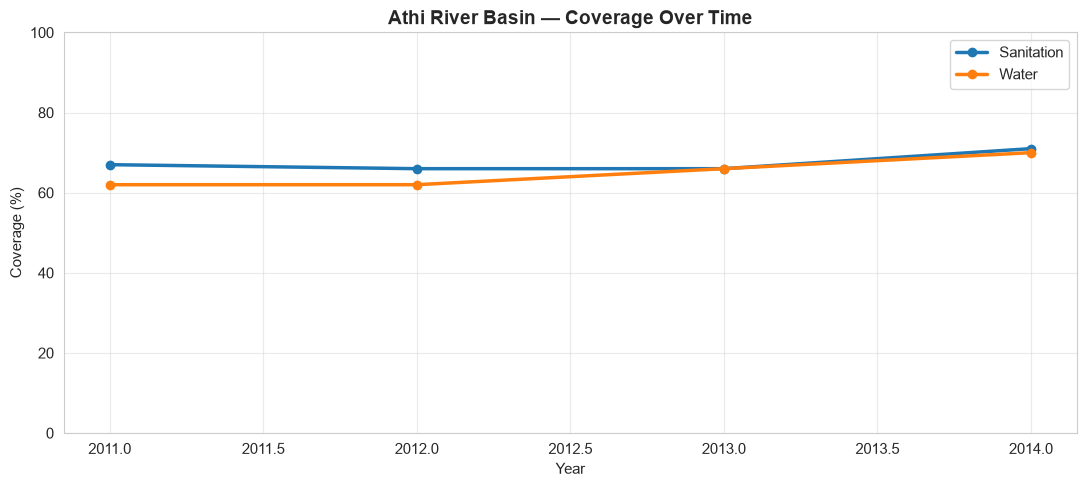


📝 Between 2011 and 2014, water coverage moved from 62% to 70% (+8 pp) and sanitation from 67% to 71% (+4 pp).


In [14]:
# ============================================================
# CHART 5 — ATHI RIVER COVERAGE (fully self-contained)
# ============================================================
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Read fresh from database ---
_conn = sqlite3.connect("data/processed/kenya_water.db")
athi_fresh = pd.read_sql_query("SELECT * FROM athi_river_coverage", _conn)
_conn.close()

# --- 2. Rename columns to guaranteed-unique snake_case names ---
athi_fresh.columns = [
    "coverage_type", "date_str", "total_pop", "annual_growth",
    "coverage_pct", "additional_pop", "served_pop", "non_served_pop", "objectid"
][:len(athi_fresh.columns)]

print("Fresh athi columns:", list(athi_fresh.columns))
print("coverage_pct dtype BEFORE:", athi_fresh["coverage_pct"].dtype)
print("coverage_pct sample BEFORE:", athi_fresh["coverage_pct"].head(3).tolist())

# --- 3. Convert coverage_pct to numeric (strip % sign and any whitespace) ---
athi_fresh["coverage_pct"] = (
    athi_fresh["coverage_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
athi_fresh["coverage_pct"] = pd.to_numeric(athi_fresh["coverage_pct"], errors="coerce")

print("coverage_pct dtype AFTER:", athi_fresh["coverage_pct"].dtype)
print("coverage_pct sample AFTER:", athi_fresh["coverage_pct"].head(3).tolist())

# --- 4. Extract year from date ---
athi_fresh["year"] = pd.to_datetime(athi_fresh["date_str"], errors="coerce").dt.year

# --- 5. Build pivot with hardcoded clean names ---
pivot = athi_fresh.pivot_table(
    index="year",
    columns="coverage_type",
    values="coverage_pct",
    aggfunc="mean"
)

pivot.to_csv("output/results/athi_coverage.csv")
print("\nPivot:")
print(pivot)

# --- 6. Plot ---
fig, ax = plt.subplots(figsize=(11, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker="o", linewidth=2.5, label=str(col))
ax.set_title("Athi River Basin — Coverage Over Time", fontsize=14)
ax.set_xlabel("Year"); ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, 100)
ax.legend(); ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("output/charts/05_athi_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

# --- 7. Finding ---
w0 = pivot["Water"].iloc[0] if "Water" in pivot.columns else 0
w1 = pivot["Water"].iloc[-1] if "Water" in pivot.columns else 0
s0 = pivot["Sanitation"].iloc[0] if "Sanitation" in pivot.columns else 0
s1 = pivot["Sanitation"].iloc[-1] if "Sanitation" in pivot.columns else 0
findings.append(("Chart 5: Athi River Coverage",
    f"Between {pivot.index.min()} and {pivot.index.max()}, water coverage moved from "
    f"{w0:.0f}% to {w1:.0f}% ({w1-w0:+.0f} pp) and sanitation from {s0:.0f}% to {s1:.0f}% ({s1-s0:+.0f} pp)."))
print(f"\n📝 {findings[-1][1]}")

  coverage_type    Served  Unserved
0    Sanitation  14867387   7301000
1         Water  14562533   7699611


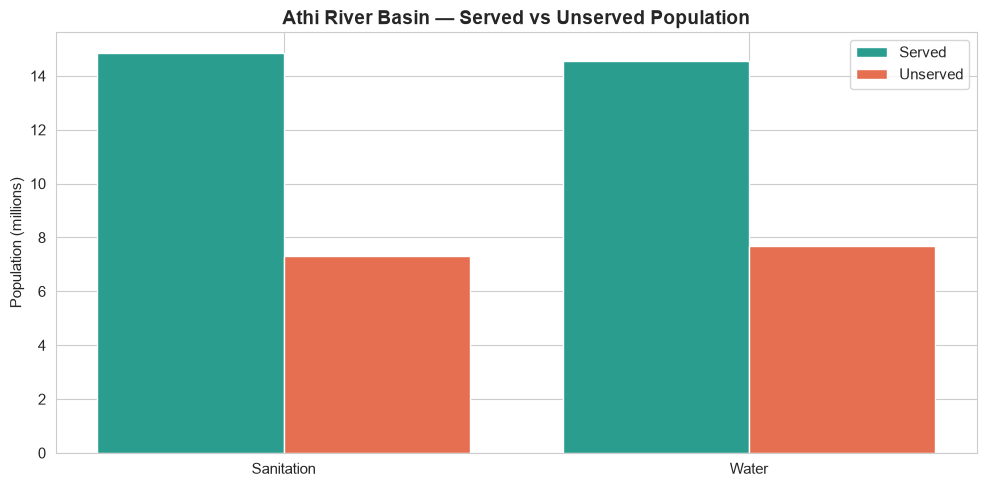


📝 Sanitation: 67.1% served, 32.9% unserved.

📝 Water: 65.4% served, 34.6% unserved.


In [15]:
# ============================================================
# CHART 6 — ATHI SERVED VS UNSERVED (fully self-contained)
# ============================================================
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

_conn = sqlite3.connect("data/processed/kenya_water.db")
athi_fresh2 = pd.read_sql_query("SELECT * FROM athi_river_coverage", _conn)
_conn.close()

athi_fresh2.columns = [
    "coverage_type", "date_str", "total_pop", "annual_growth",
    "coverage_pct", "additional_pop", "served_pop", "non_served_pop", "objectid"
][:len(athi_fresh2.columns)]

# Force numeric
athi_fresh2["served_pop"]     = pd.to_numeric(athi_fresh2["served_pop"], errors="coerce")
athi_fresh2["non_served_pop"] = pd.to_numeric(athi_fresh2["non_served_pop"], errors="coerce")

# Aggregate
summary = athi_fresh2.groupby("coverage_type").agg(
    Served=("served_pop", "sum"),
    Unserved=("non_served_pop", "sum")
).reset_index()

summary.to_csv("output/results/athi_summary.csv", index=False)
print(summary)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary)); w = 0.4
ax.bar(x - w/2, summary["Served"]/1e6, w, label="Served", color="#2a9d8f")
ax.bar(x + w/2, summary["Unserved"]/1e6, w, label="Unserved", color="#e76f51")
ax.set_xticks(x); ax.set_xticklabels(summary["coverage_type"])
ax.set_title("Athi River Basin — Served vs Unserved Population", fontsize=14)
ax.set_ylabel("Population (millions)")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/06_athi_served_vs_unserved.png", dpi=150, bbox_inches="tight")
plt.show()

for _, r in summary.iterrows():
    pct = r["Served"] / (r["Served"] + r["Unserved"]) * 100
    findings.append((f"Chart 6: {r['coverage_type']} in Athi",
        f"{r['coverage_type']}: {pct:.1f}% served, {100-pct:.1f}% unserved."))
    print(f"\n📝 {findings[-1][1]}")

        source  tests
      Borehole    188
      Effluent     74
Final Effluent     24
       Unknown     22
           Tap     20
  Shallow well     17
           Dam     15
          Rain     12
         Other    121


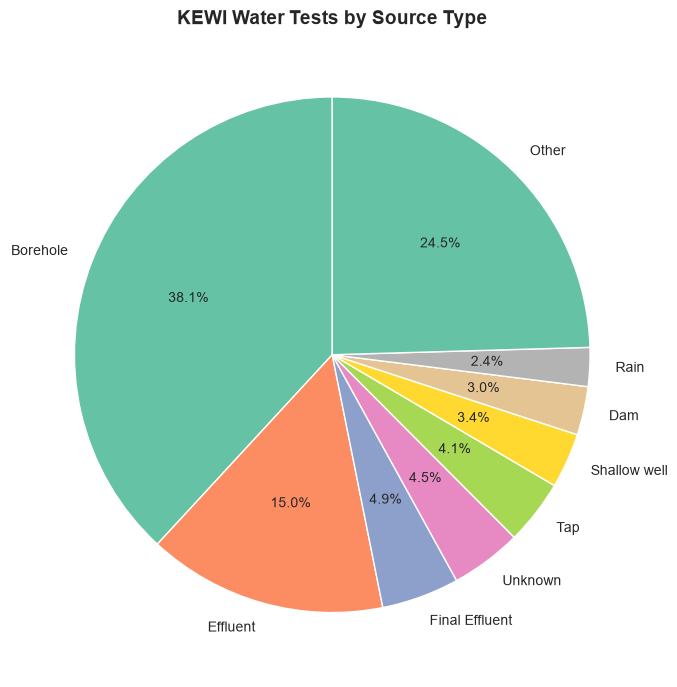


📝 Most tested source: 'Borehole' with 188 tests (38.1% of total).


In [16]:
# ============================================================
# CHART 7 — WATER SOURCE BREAKDOWN (self-contained)
# ============================================================
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_conn = sqlite3.connect("data/processed/kenya_water.db")
kewi_fresh = pd.read_sql_query("SELECT * FROM kewi_water_tests", _conn)
_conn.close()

# Hardcoded column names based on your actual DB schema
SOURCE_COL = "TYPE_OF_H2O"

# Clean nulls
kewi_fresh[SOURCE_COL] = kewi_fresh[SOURCE_COL].fillna("Unknown").astype(str).str.strip()

# Count
breakdown = kewi_fresh[SOURCE_COL].value_counts().reset_index()
breakdown.columns = ["source", "tests"]
breakdown.to_csv("output/results/07_kewi_source_breakdown.csv", index=False)

# Limit to top 8 to keep the pie readable
top = breakdown.head(8).copy()
if len(breakdown) > 8:
    other = pd.DataFrame([{"source": "Other", "tests": breakdown.iloc[8:]["tests"].sum()}])
    top = pd.concat([top, other], ignore_index=True)

print(top.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Set2", len(top))
ax.pie(top["tests"], labels=top["source"], autopct="%1.1f%%",
       colors=colors, startangle=90, textprops={"fontsize": 10})
ax.set_title("KEWI Water Tests by Source Type", fontsize=14)
plt.tight_layout()
plt.savefig("output/charts/07_source_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()

top_src = breakdown.iloc[0]
findings.append(("Chart 7: Source Breakdown",
    f"Most tested source: '{top_src['source']}' with {top_src['tests']} tests "
    f"({top_src['tests']/len(kewi_fresh)*100:.1f}% of total)."))
print(f"\n📝 {findings[-1][1]}")

Samples with both pH and conductivity: 376


C:\Users\user\AppData\Local\Temp\ipykernel_17052\742157017.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


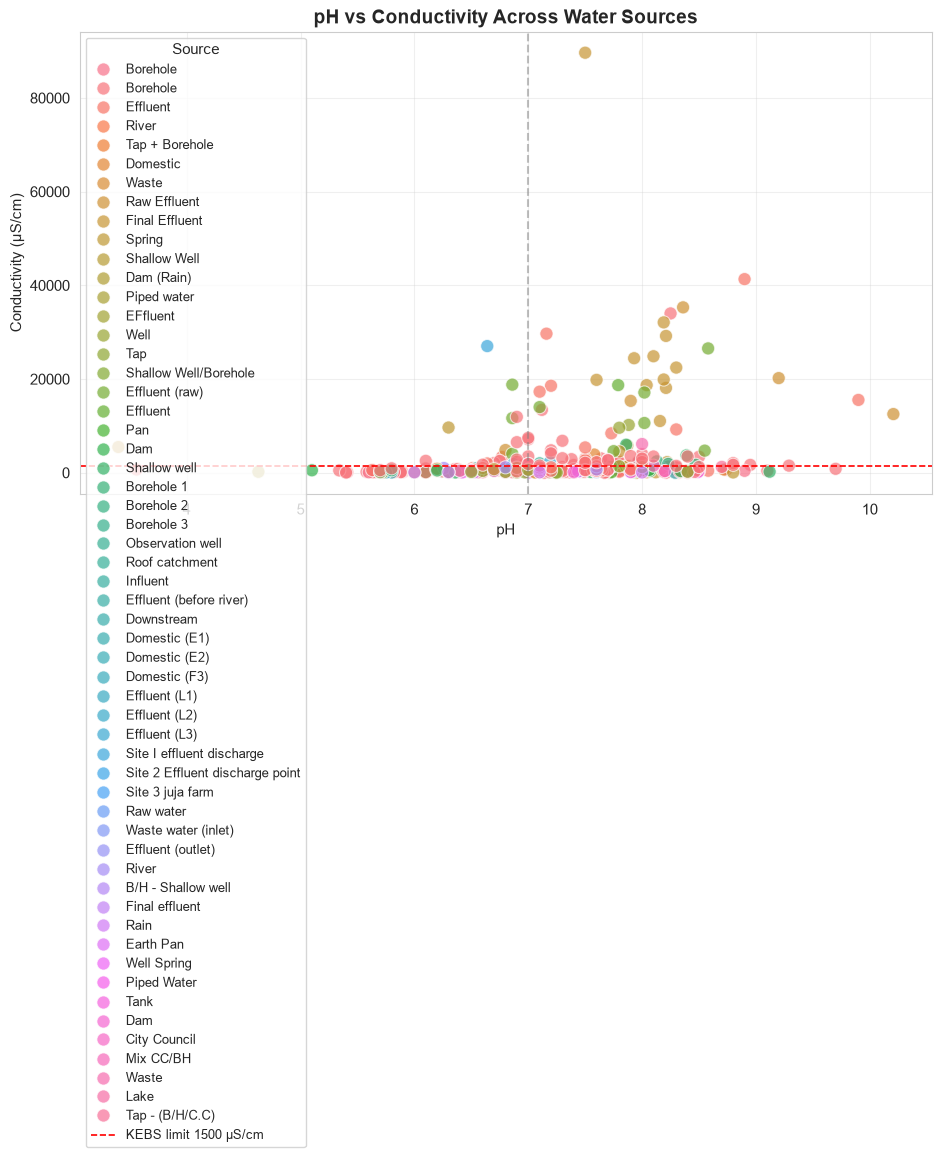


📝 103 of 376 samples exceeded the KEBS conductivity limit of 1500 µS/cm.


In [17]:
# ============================================================
# CHART 8 — pH vs CONDUCTIVITY (self-contained)
# ============================================================
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_conn = sqlite3.connect("data/processed/kenya_water.db")
kewi_fresh2 = pd.read_sql_query("SELECT * FROM kewi_water_tests", _conn)
_conn.close()

# Hardcoded column names from your DB
PH_COL    = "PH"
COND_COL  = "CONDUCTIVITY?S/cm"     # NOTE: contains the mangled µ character
SOURCE_COL = "TYPE_OF_H2O"

# Force numeric conversion on the mangled conductivity column
kewi_fresh2[PH_COL]   = pd.to_numeric(kewi_fresh2[PH_COL], errors="coerce")
kewi_fresh2[COND_COL] = pd.to_numeric(kewi_fresh2[COND_COL], errors="coerce")

# Drop rows with both missing
scatter = kewi_fresh2.dropna(subset=[PH_COL, COND_COL])
print(f"Samples with both pH and conductivity: {len(scatter)}")

if len(scatter) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.scatterplot(data=scatter, x=PH_COL, y=COND_COL,
                    hue=SOURCE_COL, s=90, alpha=0.7, ax=ax)
    ax.axvline(7.0, color="gray", linestyle="--", alpha=0.5)
    ax.axhline(1500, color="red", linestyle="--", linewidth=1.2,
               label="KEBS limit 1500 µS/cm")
    ax.set_title("pH vs Conductivity Across Water Sources", fontsize=14)
    ax.set_xlabel("pH"); ax.set_ylabel("Conductivity (µS/cm)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=9, title="Source")
    plt.tight_layout()
    plt.savefig("output/charts/08_ph_vs_conductivity.png", dpi=150, bbox_inches="tight")
    plt.show()

    above = (scatter[COND_COL] > 1500).sum()
    findings.append(("Chart 8: pH vs Conductivity",
        f"{above} of {len(scatter)} samples exceeded the KEBS conductivity limit of 1500 µS/cm."))
    print(f"\n📝 {findings[-1][1]}")
else:
    print("⚠️ No samples have both pH and conductivity — skipping Chart 8")

In [25]:
# ============================================================
# FINAL SUMMARY OF ALL FINDINGS
# ============================================================
import os

print("=" * 70)
print("📋 SUMMARY OF FINDINGS")
print("=" * 70)

for title, finding in findings:
    print(f"\n▸ {title}")
    print(f"  {finding}")

# Save to file
os.makedirs("output/results", exist_ok=True)
with open("output/results/FINDINGS.txt", "w") as f:
    for title, finding in findings:
        f.write(f"{title}\n{finding}\n\n")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE")
print(f"   Charts saved: output/charts/")
for f in sorted(os.listdir("output/charts")):
    print(f"      {f}")
print(f"\n   Results saved: output/results/")
for f in sorted(os.listdir("output/results")):
    print(f"      {f}")
print(f"\n   Findings file: output/results/FINDINGS.txt")
print("=" * 70)

📋 SUMMARY OF FINDINGS

▸ Chart 1: National WASH Trends
  Between 2000 and 2024, basic drinking water access rose from 45.4% to 65.6% (+20.2 pp). Basic sanitation rose from 23.6% to 40.9% (+17.2 pp). Open defecation fell from 16.9% to 5.9% (−11.0 pp). Sanitation still lags water access by 24.7 pp.

▸ Chart 2: Freshwater Withdrawal
  Freshwater withdrawal rose from 7.5% in 2000 to 19.5% in 2022 — still below the 25% water stress threshold but rising steadily.

▸ Chart 3: pH by County
  Average pH ranged from 5.76 (Mandera) to 8.13 (Marsabit). 13 of 14 counties fall within the KEBS range 6.5–8.5.

▸ Chart 4: Conductivity by Source
  Final Effluent had the highest average conductivity at 16446.1 µS/cm (n=21). This exceeds the KEBS limit of 1500 µS/cm.

▸ Chart 5: Athi River Coverage
  Between 2011 and 2014, water coverage moved from 62% to 70% (+8 pp) and sanitation from 67% to 71% (+4 pp).

▸ Chart 6: Sanitation in Athi
  Sanitation: 67.1% served, 32.9% unserved.

▸ Chart 6: Water in Athi

UnicodeEncodeError: 'charmap' codec can't encode character '\u2212' in position 214: character maps to <undefined>

In [27]:
# ============================================================
# FINAL SUMMARY OF ALL FINDINGS
# ============================================================
import os

print("=" * 70)
print("📋 SUMMARY OF FINDINGS")
print("=" * 70)

for title, finding in findings:
    print(f"\n▸ {title}")
    print(f"  {finding}")

# Save to file — UTF-8 encoding to handle special characters
os.makedirs("output/results", exist_ok=True)
with open("output/results/FINDINGS.txt", "w", encoding="utf-8") as f:
    for title, finding in findings:
        f.write(f"{title}\n{finding}\n\n")

print("\n" + "=" * 70)
print("✅ ANALYSIS COMPLETE")
print(f"   Charts saved: output/charts/")
for file in sorted(os.listdir("output/charts")):
    print(f"      {file}")
print(f"\n   Results saved: output/results/")
for file in sorted(os.listdir("output/results")):
    print(f"      {file}")
print(f"\n   Findings file: output/results/FINDINGS.txt")
print("=" * 70)

📋 SUMMARY OF FINDINGS

▸ Chart 1: National WASH Trends
  Between 2000 and 2024, basic drinking water access rose from 45.4% to 65.6% (+20.2 pp). Basic sanitation rose from 23.6% to 40.9% (+17.2 pp). Open defecation fell from 16.9% to 5.9% (−11.0 pp). Sanitation still lags water access by 24.7 pp.

▸ Chart 2: Freshwater Withdrawal
  Freshwater withdrawal rose from 7.5% in 2000 to 19.5% in 2022 — still below the 25% water stress threshold but rising steadily.

▸ Chart 3: pH by County
  Average pH ranged from 5.76 (Mandera) to 8.13 (Marsabit). 13 of 14 counties fall within the KEBS range 6.5–8.5.

▸ Chart 4: Conductivity by Source
  Final Effluent had the highest average conductivity at 16446.1 µS/cm (n=21). This exceeds the KEBS limit of 1500 µS/cm.

▸ Chart 5: Athi River Coverage
  Between 2011 and 2014, water coverage moved from 62% to 70% (+8 pp) and sanitation from 67% to 71% (+4 pp).

▸ Chart 6: Sanitation in Athi
  Sanitation: 67.1% served, 32.9% unserved.

▸ Chart 6: Water in Athi

In [20]:
import os
print(f"Charts in output/charts/: {len(os.listdir('output/charts'))}")
for f in sorted(os.listdir("output/charts")):
    print(f"  {f}")

Charts in output/charts/: 0


REGENERATE

In [26]:
import os
import re
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_DIR = r"C:\Users\user\Desktop\Final Project"
os.chdir(PROJECT_DIR)
os.makedirs("output/charts", exist_ok=True)
os.makedirs("output/results", exist_ok=True)

print(f"Working dir: {os.getcwd()}")
print(f"Charts dir exists: {os.path.exists('output/charts')}")
print(f"Database exists: {os.path.exists('data/processed/kenya_water.db')}")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titleweight"] = "bold"

KEBS = {"ph_min": 6.5, "ph_max": 8.5, "conductivity": 2500,
        "tds": 1000, "alkalinity": 500, "colour": 15}

# ---------- Load ----------
conn = sqlite3.connect("data/processed/kenya_water.db")
kewi = pd.read_sql_query("SELECT * FROM kewi_water_tests", conn)
conn.close()
print(f"Loaded {len(kewi)} samples")

# ---------- Column detection ----------
def norm(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower())

def find_col(df, candidates):
    cols_norm = {c: norm(c) for c in df.columns}
    for cand in candidates:
        cn = norm(cand)
        for c, ccn in cols_norm.items():
            if cn == ccn or cn in ccn or ccn in cn:
                return c
    return None

COL_COUNTY = find_col(kewi, ["COUNTY"])
COL_SOURCE = find_col(kewi, ["TYPE_OF_H2O", "TYPE_OF_WATER"])
COL_PH     = find_col(kewi, ["PH"])
COL_COND   = find_col(kewi, ["CONDUCTIVITY"])
COL_TDS    = find_col(kewi, ["TOTAL_DISSOLVED", "TDS"])
COL_ALK    = find_col(kewi, ["ALKALINITY"])
COL_COLOUR = find_col(kewi, ["COLOUR"])

for col in [COL_PH, COL_COND, COL_TDS, COL_ALK, COL_COLOUR]:
    if col:
        kewi[col + "_num"] = pd.to_numeric(kewi[col], errors="coerce")

PH   = COL_PH + "_num"     if COL_PH else None
COND = COL_COND + "_num"   if COL_COND else None
TDS  = COL_TDS + "_num"    if COL_TDS else None
ALK  = COL_ALK + "_num"    if COL_ALK else None
COL  = COL_COLOUR + "_num" if COL_COLOUR else None

kewi[COL_COUNTY] = kewi[COL_COUNTY].astype(str).str.strip()
kewi[COL_SOURCE] = kewi[COL_SOURCE].astype(str).str.strip()

# ---------- County cleaning ----------
KENYA_COUNTIES = [
    "Baringo", "Bomet", "Bungoma", "Busia", "Elgeyo-Marakwet", "Embu",
    "Garissa", "Homa Bay", "Isiolo", "Kajiado", "Kakamega", "Kericho",
    "Kiambu", "Kilifi", "Kirinyaga", "Kisii", "Kisumu", "Kitui",
    "Kwale", "Laikipia", "Lamu", "Machakos", "Makueni", "Mandera",
    "Marsabit", "Meru", "Migori", "Mombasa", "Murang'a", "Nairobi",
    "Nakuru", "Nandi", "Narok", "Nyamira", "Nyandarua", "Nyeri",
    "Samburu", "Siaya", "Taita-Taveta", "Tana River", "Tharaka-Nithi",
    "Trans Nzoia", "Turkana", "Uasin Gishu", "Vihiga", "Wajir", "West Pokot"
]

KENYA_LOOKUP = {norm(c): c for c in KENYA_COUNTIES}
VARIANT_MAP = {
    "homabay": "Homa Bay", "sondu": "Kisumu", "nyando": "Kisumu",
    "kisumueast": "Kisumu", "lodwar": "Turkana", "lokichoggio": "Turkana",
    "mwingi": "Kitui", "thika": "Kiambu", "taitataveta": "Taita-Taveta",
    "tharakantihi": "Tharaka-Nithi", "elgeyomarakwet": "Elgeyo-Marakwet",
    "muranga": "Murang'a",
}
NON_KENYAN = {"somalia", "mogadishu", "mogadishusomalia",
              "moshitanzania", "iringatanzania", "iringa",
              "northernbaherelghazalsouthernsudan",
              "central", "riftvalley"}

def map_county(raw):
    if pd.isna(raw):
        return None
    key = norm(raw)
    if key in KENYA_LOOKUP:
        return KENYA_LOOKUP[key]
    if key in VARIANT_MAP:
        return VARIANT_MAP[key]
    if key in NON_KENYAN:
        return None
    return str(raw)

kewi["county_clean"] = kewi[COL_COUNTY].apply(map_county)
kewi_ke = kewi[kewi["county_clean"].notna()].copy()
print(f"Kenyan samples: {len(kewi_ke)} across {kewi_ke['county_clean'].nunique()} counties")

# ============================================================
# CHART 1 — pH Distribution
# ============================================================
fig, ax = plt.subplots()
sns.histplot(kewi[PH].dropna(), bins=40, kde=True, color="#0077b6", ax=ax)
ax.axvline(KEBS["ph_min"], color="red", linestyle="--", linewidth=1.5, label="KEBS min (6.5)")
ax.axvline(KEBS["ph_max"], color="red", linestyle="--", linewidth=1.5, label="KEBS max (8.5)")
ax.axvline(7.0, color="green", linestyle=":", linewidth=1, label="Neutral (7.0)")
ax.set_title("pH Distribution Across All Samples")
ax.set_xlabel("pH"); ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/01_ph_distribution.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 01_ph_distribution.png")

# ============================================================
# CHART 2 — pH by Source Type
# ============================================================
src_data = kewi[[COL_SOURCE, PH]].dropna()
top_src = src_data[COL_SOURCE].value_counts().head(6).index
src_data = src_data[src_data[COL_SOURCE].isin(top_src)]
order = src_data.groupby(COL_SOURCE)[PH].median().sort_values().index

fig, ax = plt.subplots()
sns.boxplot(data=src_data, x=COL_SOURCE, y=PH, order=order, palette="viridis", ax=ax)
ax.axhline(KEBS["ph_min"], color="red", linestyle="--", linewidth=1.2, label="KEBS min")
ax.axhline(KEBS["ph_max"], color="red", linestyle="--", linewidth=1.2, label="KEBS max")
ax.set_title("pH by Water Source Type")
ax.set_xlabel("Source type"); ax.set_ylabel("pH")
ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout()
plt.savefig("output/charts/02_ph_by_source.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 02_ph_by_source.png")

# ============================================================
# CHART 3 — pH by County (n ≥ 5)
# ============================================================
by_county = kewi_ke.groupby("county_clean")[PH].agg(["mean", "count"]).reset_index()
by_county.columns = ["county", "avg_ph", "n"]
by_county = by_county[by_county["n"] >= 5].sort_values("avg_ph")
by_county.to_csv("output/results/ph_by_county.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(by_county)*0.4)))
colors = ["#e63946" if (v < KEBS["ph_min"] or v > KEBS["ph_max"]) else "#2a9d8f"
          for v in by_county["avg_ph"]]
ax.barh(by_county["county"], by_county["avg_ph"], color=colors)
ax.axvline(KEBS["ph_min"], color="red", linestyle="--", linewidth=1.2, label="KEBS min")
ax.axvline(KEBS["ph_max"], color="red", linestyle="--", linewidth=1.2, label="KEBS max")
ax.set_title("Average pH by County (n ≥ 5 samples)")
ax.set_xlabel("Average pH"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("output/charts/03_ph_by_county.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 03_ph_by_county.png")

# ============================================================
# CHART 4 — Conductivity Distribution
# ============================================================
fig, ax = plt.subplots()
sns.histplot(kewi[COND].dropna(), bins=40, kde=True, color="#2a9d8f", ax=ax)
ax.axvline(KEBS["conductivity"], color="red", linestyle="--", linewidth=1.5,
           label=f"KEBS limit ({KEBS['conductivity']} µS/cm)")
ax.set_title("Conductivity Distribution Across All Samples")
ax.set_xlabel("Conductivity (µS/cm)"); ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/04_conductivity_distribution.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 04_conductivity_distribution.png")

# ============================================================
# CHART 5 — Conductivity by Source
# ============================================================
src_cond = kewi[[COL_SOURCE, COND]].dropna()
top_src = src_cond[COL_SOURCE].value_counts().head(6).index
src_cond = src_cond[src_cond[COL_SOURCE].isin(top_src)]
avg_cond = src_cond.groupby(COL_SOURCE)[COND].mean().sort_values(ascending=False)

fig, ax = plt.subplots()
sns.barplot(x=avg_cond.index, y=avg_cond.values, palette="crest", ax=ax)
ax.axhline(KEBS["conductivity"], color="red", linestyle="--", linewidth=1.2,
           label=f"KEBS limit ({KEBS['conductivity']} µS/cm)")
ax.set_title("Average Conductivity by Water Source Type")
ax.set_xlabel("Source type"); ax.set_ylabel("Conductivity (µS/cm)")
ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout()
plt.savefig("output/charts/05_conductivity_by_source.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 05_conductivity_by_source.png")

# ============================================================
# CHART 6 — Conductivity by County (n ≥ 5)
# ============================================================
cond_county = kewi_ke.groupby("county_clean")[COND].agg(["mean", "count"]).reset_index()
cond_county.columns = ["county", "avg_cond", "n"]
cond_county = cond_county[cond_county["n"] >= 5].sort_values("avg_cond", ascending=False)
cond_county.to_csv("output/results/conductivity_by_county.csv", index=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(cond_county)*0.4)))
colors = ["#e63946" if v > KEBS["conductivity"] else "#2a9d8f" for v in cond_county["avg_cond"]]
ax.barh(cond_county["county"], cond_county["avg_cond"], color=colors)
ax.axvline(KEBS["conductivity"], color="red", linestyle="--", linewidth=1.2,
           label=f"KEBS limit ({KEBS['conductivity']} µS/cm)")
ax.set_title("Average Conductivity by County (n ≥ 5 samples)")
ax.set_xlabel("Conductivity (µS/cm)"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("output/charts/06_conductivity_by_county.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 06_conductivity_by_county.png")

# ============================================================
# CHART 7 — TDS Distribution
# ============================================================
fig, ax = plt.subplots()
sns.histplot(kewi[TDS].dropna(), bins=40, kde=True, color="#e76f51", ax=ax)
ax.axvline(KEBS["tds"], color="red", linestyle="--", linewidth=1.5,
           label=f"KEBS limit ({KEBS['tds']} mg/L)")
ax.set_title("Total Dissolved Solids (TDS) Distribution")
ax.set_xlabel("TDS (mg/L)"); ax.set_ylabel("Number of samples")
ax.legend()
plt.tight_layout()
plt.savefig("output/charts/07_tds_distribution.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 07_tds_distribution.png")

# ============================================================
# CHART 8 — Correlation Heatmap
# ============================================================
corr_cols = [c for c in [PH, COND, TDS, ALK, COL] if c]
corr_data = kewi[corr_cols].dropna(how="all")
corr_matrix = corr_data.corr()
corr_matrix.to_csv("output/results/correlation_matrix.csv")

labels = [c.replace("_num", "") for c in corr_cols]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0,
            xticklabels=labels, yticklabels=labels, fmt=".2f",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Between Water Quality Parameters")
plt.tight_layout()
plt.savefig("output/charts/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("✅ 08_correlation_heatmap.png")

print(f"\n✅ DONE. {len(os.listdir('output/charts'))} charts in output/charts/")

Working dir: c:\Users\user\Desktop\Final Project
Charts dir exists: True
Database exists: True
Loaded 493 samples
Kenyan samples: 469 across 37 counties
✅ 01_ph_distribution.png


C:\Users\user\AppData\Local\Temp\ipykernel_17052\2290450816.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=src_data, x=COL_SOURCE, y=PH, order=order, palette="viridis", ax=ax)


✅ 02_ph_by_source.png
✅ 03_ph_by_county.png
✅ 04_conductivity_distribution.png


C:\Users\user\AppData\Local\Temp\ipykernel_17052\2290450816.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_cond.index, y=avg_cond.values, palette="crest", ax=ax)


✅ 05_conductivity_by_source.png
✅ 06_conductivity_by_county.png
✅ 07_tds_distribution.png
✅ 08_correlation_heatmap.png

✅ DONE. 8 charts in output/charts/
